In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# better plots
sns.set(style="whitegrid")


In [3]:
def Students_Perfomance(data_path=r"C:\Users\nooth\Downloads"):
    csv_path = os.path.join(data_path,"StudentsPerfomance")
    return pd.read_csv(csv_path)

In [4]:

df = pd.read_csv("C:/Users/nooth/Downloads/archive (2)/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
df.info()
df.shape
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
df.isnull().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
df.columns


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

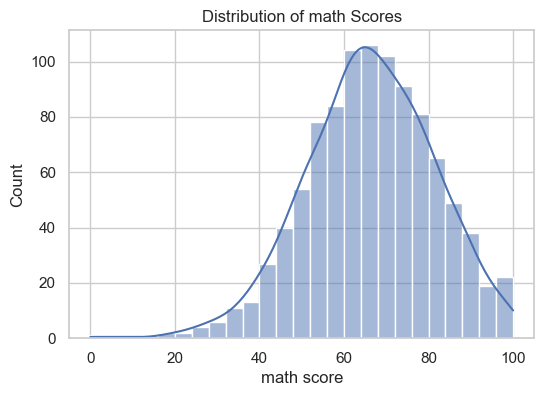

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['math score'], kde=True)
plt.title("Distribution of math Scores")
plt.show()


In [15]:
df['ExamScore'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3



In [16]:
np.random.seed(42)
df['StudyHours'] = np.random.randint(1, 10, size=len(df))


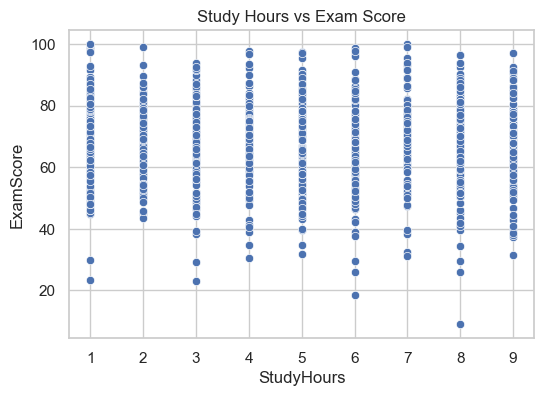

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='StudyHours', y='ExamScore', data=df)
plt.title("Study Hours vs Exam Score")
plt.show()


In [18]:
np.random.seed(0)
df['Attendance'] = np.random.choice(['Low', 'Medium', 'High'], size=len(df))


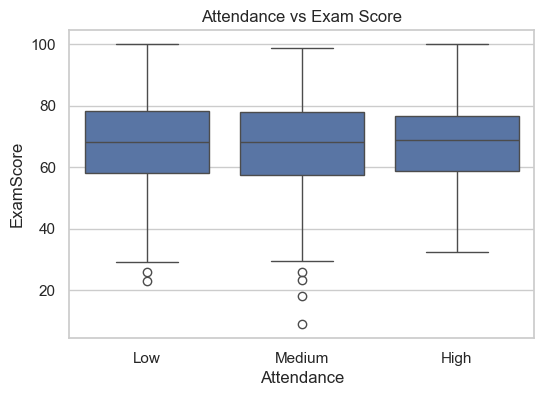

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Attendance', y='ExamScore', data=df)
plt.title("Attendance vs Exam Score")
plt.show()


In [22]:
df['ExamScore'] = pd.to_numeric(df['ExamScore'])



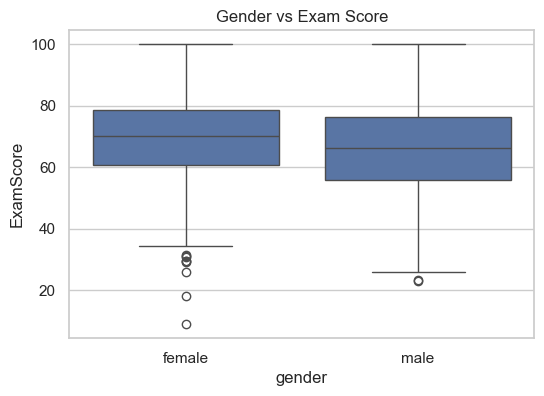

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='ExamScore', data=df)
plt.title("Gender vs Exam Score")
plt.show()


In [25]:
df['FinalResult'] = np.where(df['ExamScore'] >= 50, 'Pass', 'Fail')


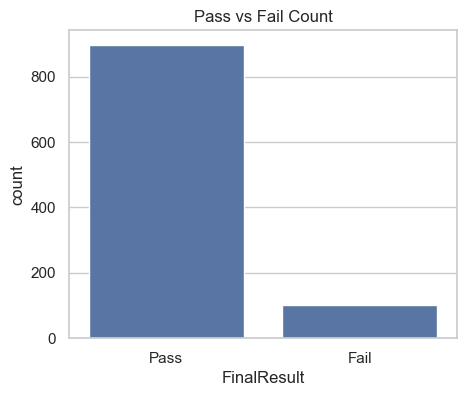

In [26]:
plt.figure(figsize=(5,4))
sns.countplot(x='FinalResult', data=df)
plt.title("Pass vs Fail Count")
plt.show()


In [30]:
df_encoded = df.copy()
df_encoded['gender'] = df_encoded['gender'].map({'Male': 0, 'Female': 1})
df_encoded['FinalResult'] = df_encoded['FinalResult'].map({'Fail': 0, 'Pass': 1})


In [32]:
df_encoded = df_encoded.select_dtypes(include='number')


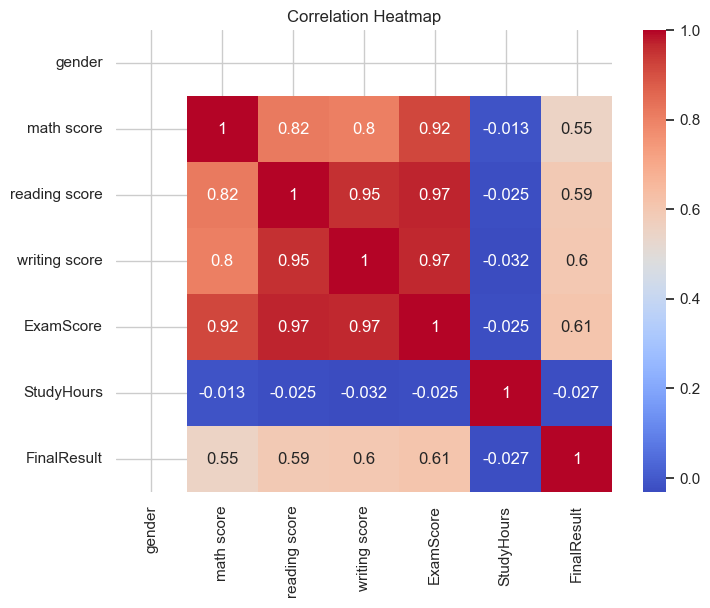

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [35]:
df.columns


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'ExamScore', 'StudyHours', 'Attendance',
       'FinalResult'],
      dtype='object')

In [36]:
df.select_dtypes(include='number').skew()


math score      -0.278935
reading score   -0.259105
writing score   -0.289444
ExamScore       -0.299057
StudyHours       0.017258
dtype: float64

In [37]:
df.groupby('gender')['ExamScore'].mean()
df.groupby('gender')['FinalResult'].value_counts()


gender  FinalResult
female  Pass           479
        Fail            39
male    Pass           418
        Fail            64
Name: count, dtype: int64

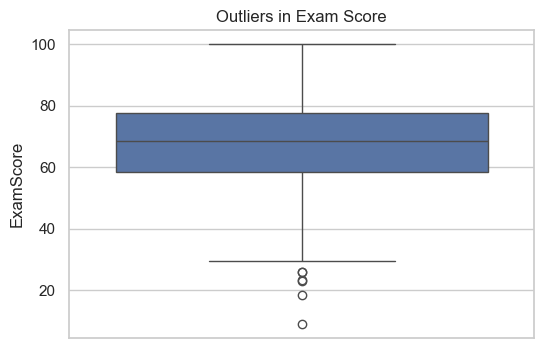

In [38]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['ExamScore'])
plt.title("Outliers in Exam Score")
plt.show()
